In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

## Part A: Theoretical objects
- Quadratic volatility function σ(S)
- Lamperti transform
- Concave vs convex plots

In [3]:
def sigma (S, a, b, c):
    return a*S**2 + b*S +c

In [4]:
def lamperti_transform(S, a, b, c):
    integrand = lambda s: 1.0 / sigma(s, a, b, c)
    val, _ = quad(integrand, 1.0, S)  # integrate from 1.0 as base
    return val

In [30]:
a, b, c = 0.05, 0, 0.2  # toy values
S_vals = np.linspace(50, 150, 200)

In [31]:
sigma_vals = [sigma(S, a, b, c) for S in S_vals]
x_vals = [lamperti_transform(S, a, b, c) for S in S_vals]


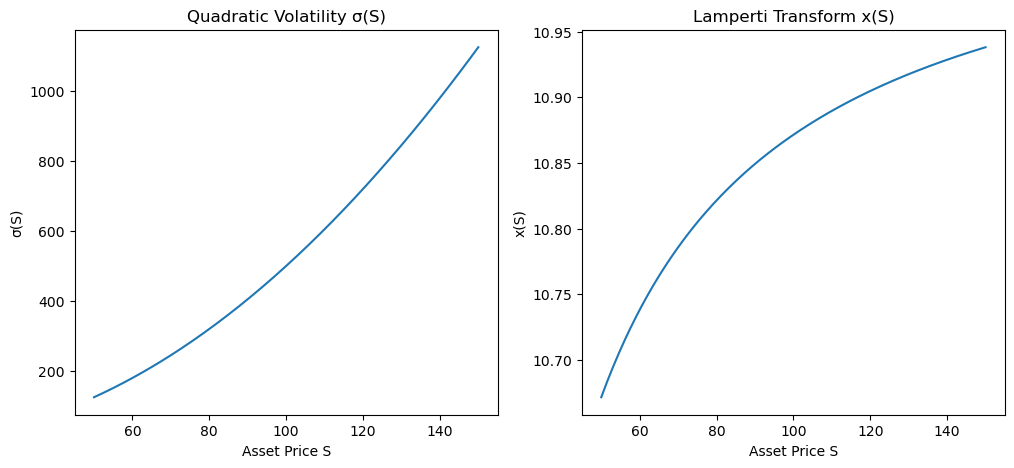

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(S_vals, sigma_vals)
ax[0].set_title("Quadratic Volatility σ(S)")
ax[0].set_xlabel("Asset Price S")
ax[0].set_ylabel("σ(S)")

ax[1].plot(S_vals, x_vals)
ax[1].set_title("Lamperti Transform x(S)")
ax[1].set_xlabel("Asset Price S")
ax[1].set_ylabel("x(S)")

plt.show()

## Part B: Market data
- Pull SPY option chain with yfinance
- Plot implied volatility smile

In [34]:
import yfinance as yf

# Get underlying
ticker = yf.Ticker("SPY")
spot = ticker.history(period="1d")['Close'].iloc[-1]
print("Spot price:", spot)

# Option expiries available
expiries = ticker.options
print("Available expiries:", expiries[:5])  # first few dates

# Pull option chain for nearest expiry
chain = ticker.option_chain(expiries[0])
calls = chain.calls[['strike', 'lastPrice', 'impliedVolatility']]
puts = chain.puts[['strike', 'lastPrice', 'impliedVolatility']]

print(calls.head())


Spot price: 661.8200073242188
Available expiries: ('2025-09-29', '2025-09-30', '2025-10-01', '2025-10-02', '2025-10-03')
   strike  lastPrice  impliedVolatility
0   565.0      94.56           1.095708
1   570.0      92.83           1.044927
2   575.0      84.03           0.995117
3   585.0      74.57           0.891114
4   600.0      60.01           0.737307


In [37]:
print(puts.head())

   strike  lastPrice  impliedVolatility
0   500.0       0.01           1.125004
1   505.0       0.02           1.093755
2   510.0       0.01           1.062505
3   515.0       0.04           1.031255
4   525.0       0.04           0.937501


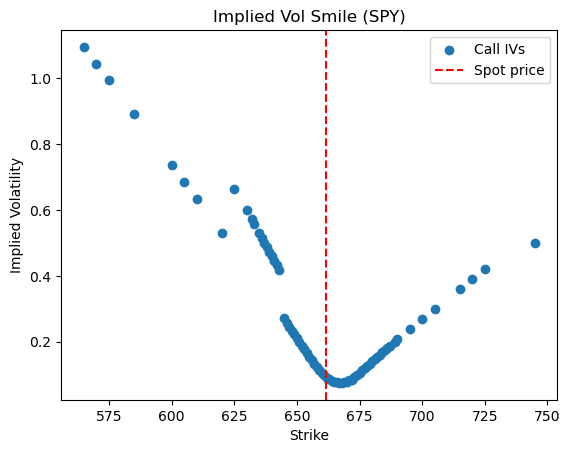

In [35]:
import matplotlib.pyplot as plt

plt.scatter(calls['strike'], calls['impliedVolatility'], label='Call IVs')
plt.axvline(spot, color='red', linestyle='--', label='Spot price')
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("Implied Vol Smile (SPY)")
plt.legend()
plt.show()


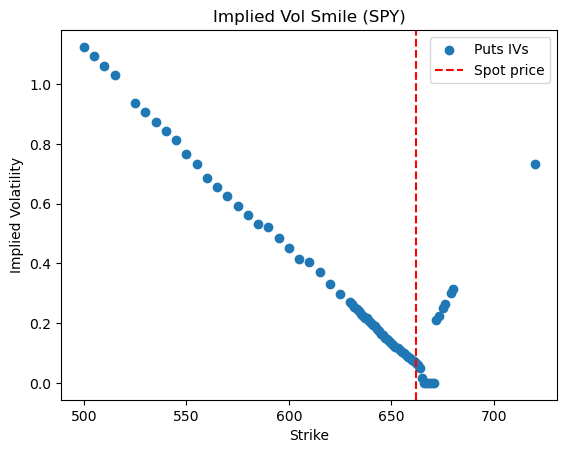

In [38]:


plt.scatter(puts['strike'], puts['impliedVolatility'], label='Puts IVs')
plt.axvline(spot, color='red', linestyle='--', label='Spot price')
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("Implied Vol Smile (SPY)")
plt.legend()
plt.show()